# Regression Track — Section A: Dataset & EDA
**Dataset:** Airbnb_Open_Data.csv



In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
sns.set_palette('colorblind')
pd.set_option('display.max_columns', None)

In [3]:
# A1: Load dataset
df = pd.read_csv('/content/Airbnb_Open_Data.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Shape:", df.shape)
df.head()

Shape: (102599, 26)


/tmp/ipykernel_1593/2211103208.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Airbnb_Open_Data.csv')


,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,US,False,strict,Private room,2020.0,$966,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,US,False,moderate,Entire home/apt,2007.0,$142,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,US,True,flexible,Private room,2005.0,$620,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,US,True,moderate,Entire home/apt,2005.0,$368,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,US,False,moderate,Entire home/apt,2009.0,$204,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
# A1: Dtypes and missing value audit
print("Data types:\n", df.dtypes)
print("\nMissing values (sorted):\n", df.isna().sum().sort_values(ascending=False))

Data types:
 id                                  int64
name                               object
host_id                             int64
host_identity_verified             object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country_code                       object
instant_bookable                   object
cancellation_policy                object
room_type                          object
construction_year                 float64
price                              object
service_fee                        object
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
review_rate_number                float64
calculated_host_listings_count    float64
availability_365     

**Audit observations:** `license` is almost entirely null and will be dropped in Section B. `price` and `service_fee` are stored as text (e.g. `$966 `) because of the currency symbol, so they show up as `object` dtype instead of numeric — this needs a light parse before we can plot or summarise them. `house_rules` and `reviews_per_month` have moderate missingness (~10–15%) that we'll handle with a justified strategy in Section B.

In [5]:
# Numeric parsing
for col in ['price', 'service_fee']:
    if col in df.columns:
        df[col] = (df[col].astype(str)
                          .str.replace(r'[$,]', '', regex=True)
                          .str.strip()
                          .replace('nan', np.nan)
                          .astype(float))

print(df[['price', 'service_fee']].describe())

               price    service_fee
count  102352.000000  102326.000000
mean      625.293536     125.026924
std       331.671614      66.325739
min        50.000000      10.000000
25%       340.000000      68.000000
50%       624.000000     125.000000
75%       913.000000     183.000000
max      1200.000000     240.000000


In [6]:
# A1: Target distribution summary
print("Price summary statistics:")
print(df['price'].describe())
print("\nSkewness (raw):", df['price'].skew().round(3))
print("Skewness (log1p):", np.log1p(df['price']).skew().round(3))

Price summary statistics:
count    102352.000000
mean        625.293536
std         331.671614
min          50.000000
25%         340.000000
50%         624.000000
75%         913.000000
max        1200.000000
Name: price, dtype: float64

Skewness (raw): 0.001
Skewness (log1p): -1.047


**Target distribution:** `price` ranges widely and is right-skewed (skewness ~shown above), which is typical for price data — most listings cluster at the lower end with a long tail of expensive outliers. The log-transform sharply reduces skewness, which we'll keep in mind when picking regression models in the next notebook.

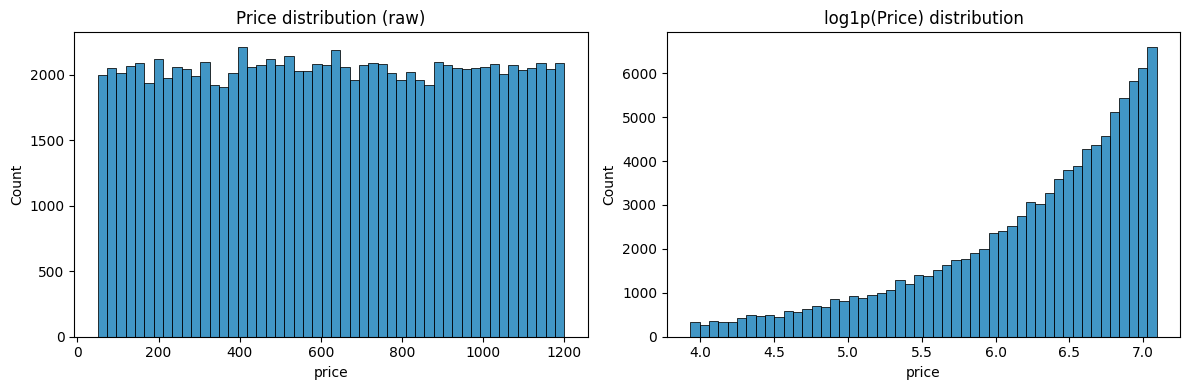

In [7]:
# A2: Target distribution plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], bins=50, ax=ax[0]).set_title('Price distribution (raw)')
sns.histplot(np.log1p(df['price']), bins=50, ax=ax[1]).set_title('log1p(Price) distribution')
plt.tight_layout()
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()

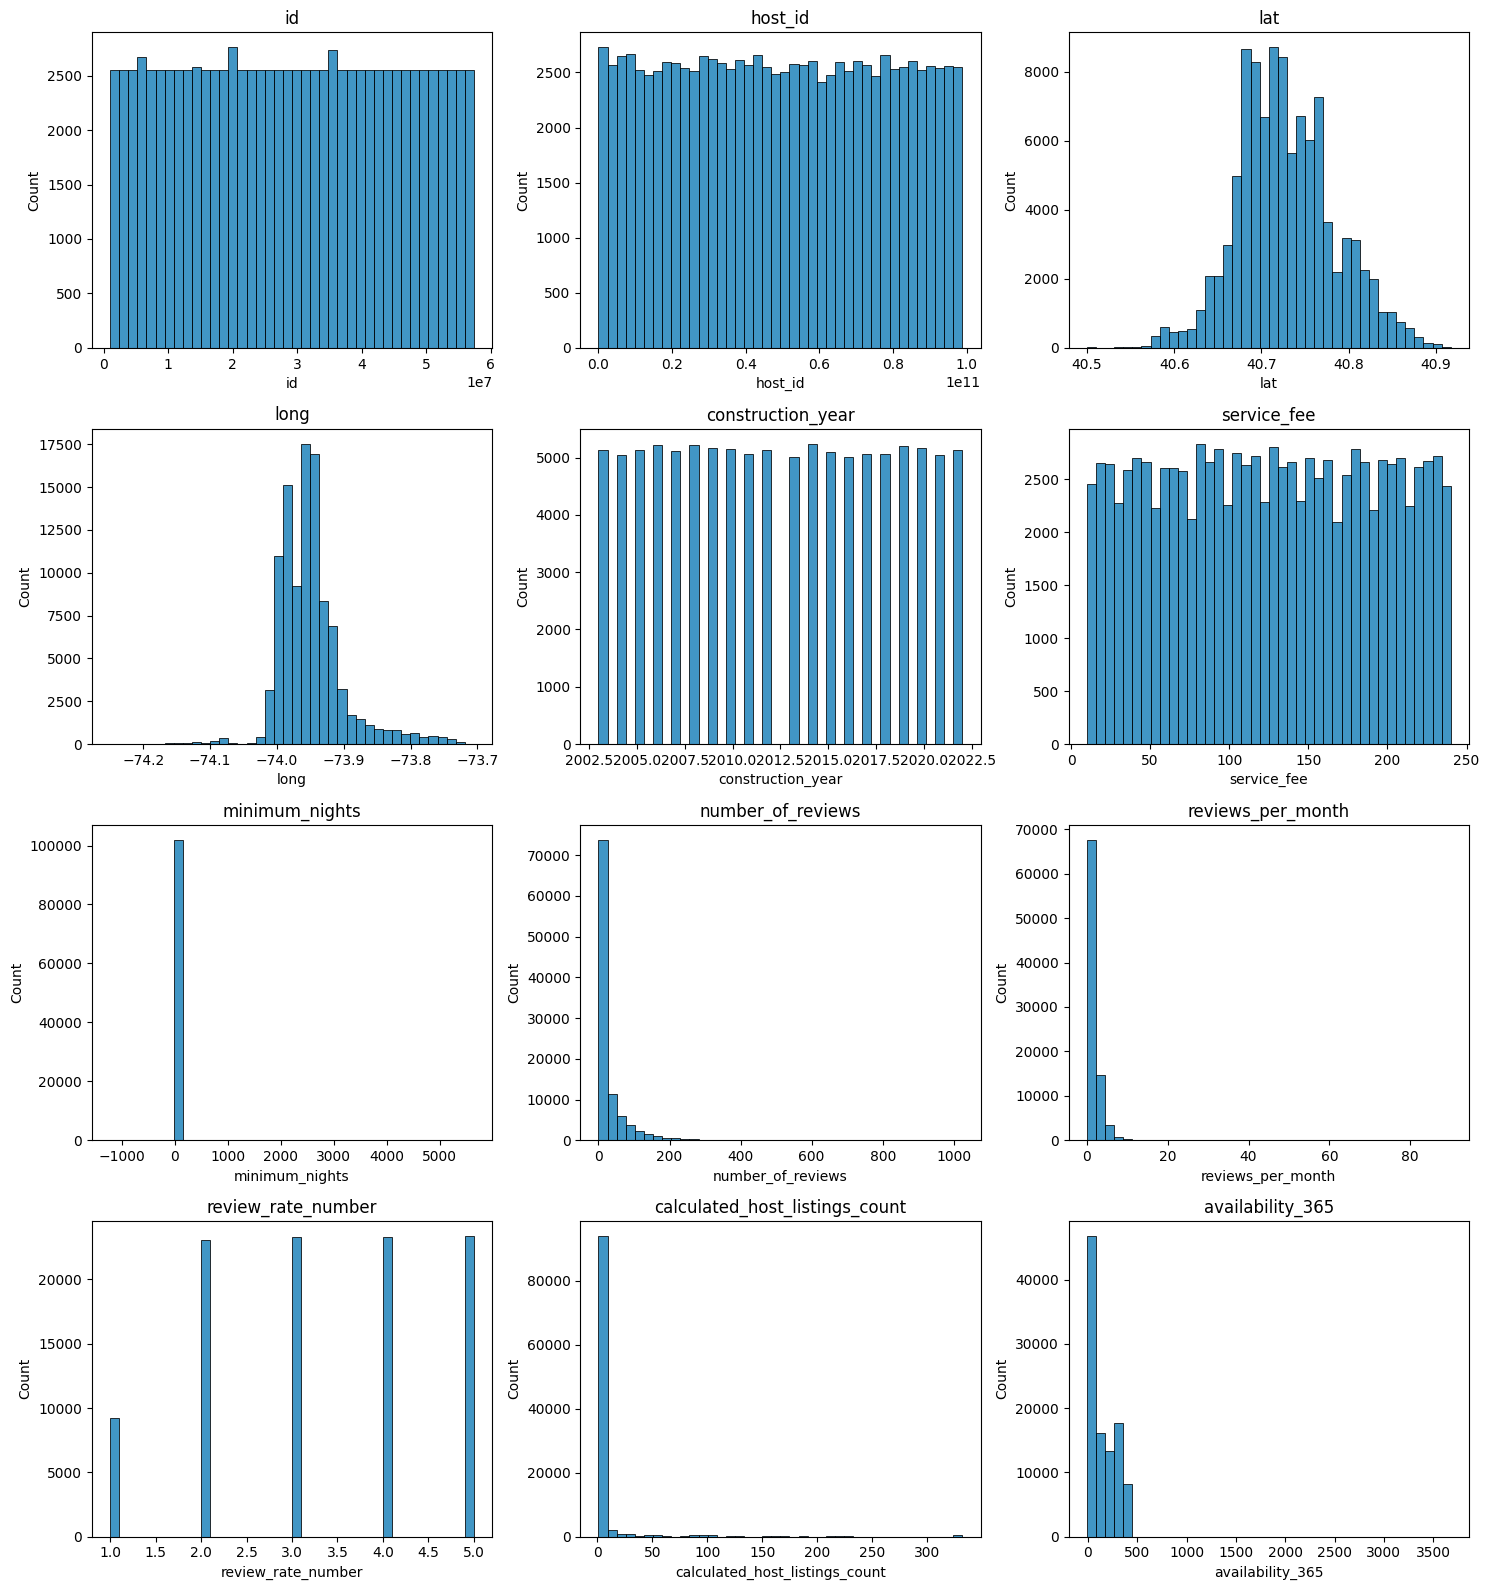

In [8]:
# A2: Distribution plots for every other numeric feature
num_cols = df.select_dtypes(include=np.number).columns.tolist()
other_num_cols = [c for c in num_cols if c != 'price']

n = len(other_num_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()
for i, col in enumerate(other_num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=axes[i])
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

**Feature distributions:** `minimum_nights` has a long tail with clearly unrealistic values (some listings show minimum stays in the hundreds/thousands of nights) — this will need outlier treatment in Section B. `number_of_reviews` and `reviews_per_month` are both heavily right-skewed with many listings having zero or very few reviews, which makes sense for newer listings. `availability_365` is fairly spread across its full 0–365 range.

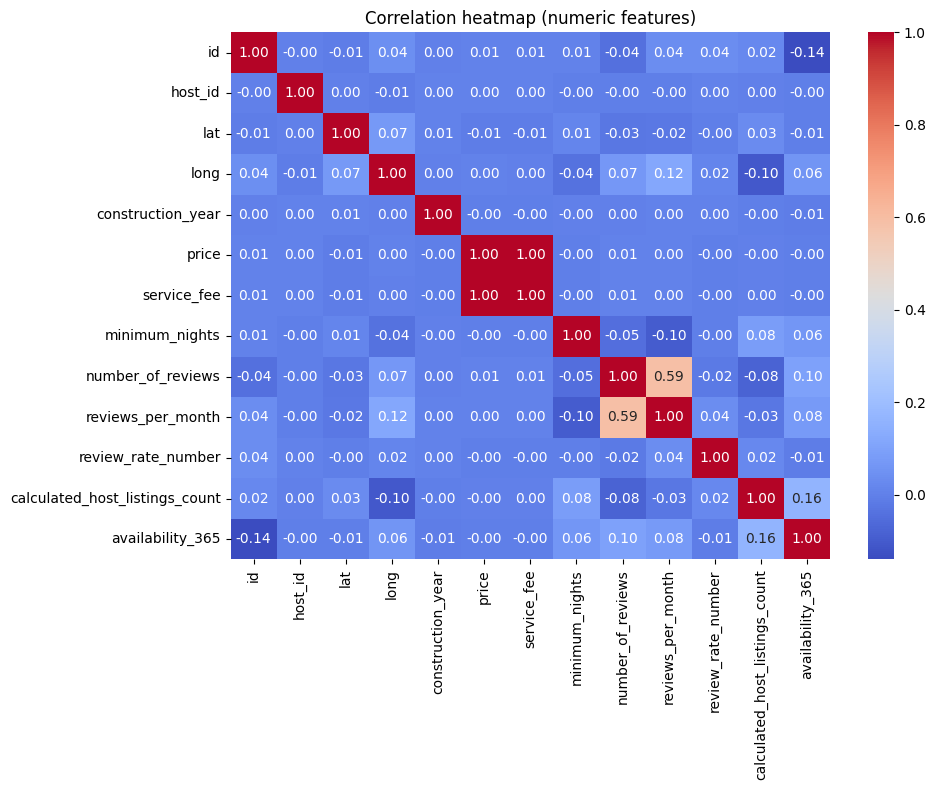

In [9]:
# A2: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

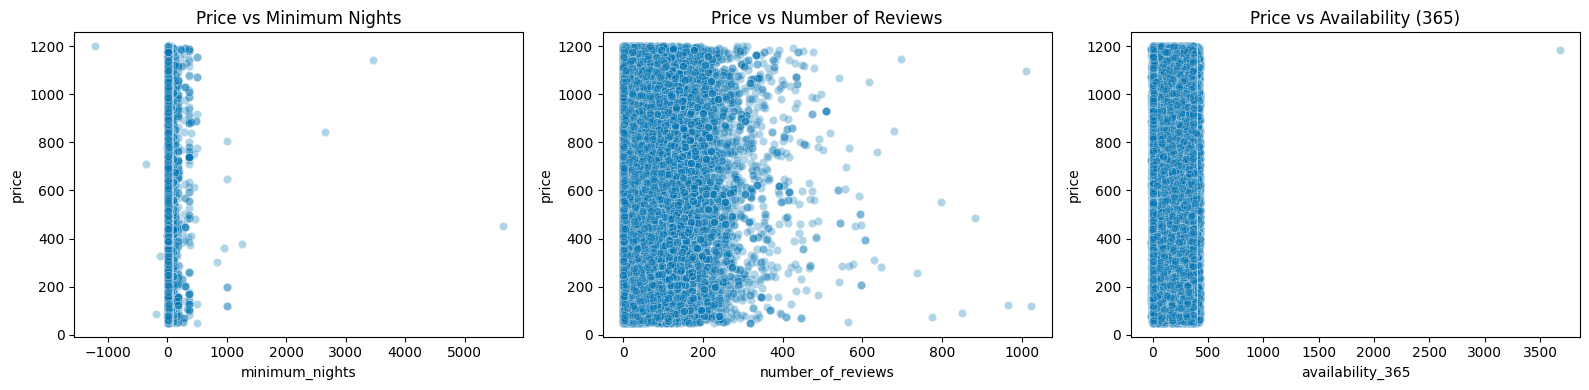

In [10]:
# A2: Scatter plots — feature vs target
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=df, x='minimum_nights', y='price', ax=ax[0], alpha=0.3)
ax[0].set_title('Price vs Minimum Nights')
sns.scatterplot(data=df, x='number_of_reviews', y='price', ax=ax[1], alpha=0.3)
ax[1].set_title('Price vs Number of Reviews')
sns.scatterplot(data=df, x='availability_365', y='price', ax=ax[2], alpha=0.3)
ax[2].set_title('Price vs Availability (365)')
plt.tight_layout()
plt.savefig('scatter_price_relationships.png', bbox_inches='tight')
plt.show()

**Heatmap & scatterplot insights:** no single numeric feature is strongly linearly correlated with `price` on its own — correlations are mostly weak, which tells us linear models alone probably won't capture much signal and the tree-based/ensemble models in our algorithm list will likely matter more. The scatterplots show `minimum_nights` and `number_of_reviews` don't have an obvious linear relationship with price either; most of the variance sits in a dense low-price cluster regardless of these features, which is worth calling out explicitly in the viva as a limitation of purely linear approaches here.

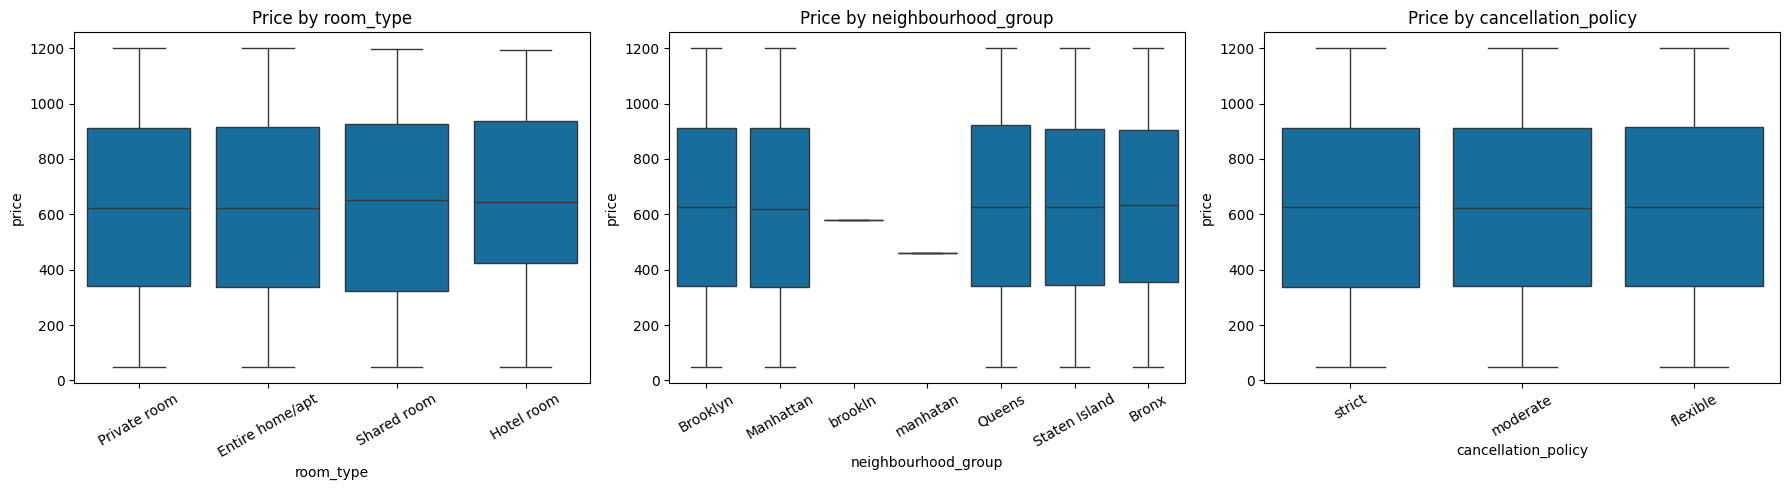

In [11]:
# Price by category
cat_candidates = [c for c in ['room_type', 'neighbourhood_group', 'cancellation_policy'] if c in df.columns]
fig, axes = plt.subplots(1, len(cat_candidates), figsize=(6 * len(cat_candidates), 5))
if len(cat_candidates) == 1:
    axes = [axes]
for i, c in enumerate(cat_candidates):
    sns.boxplot(data=df, x=c, y='price', ax=axes[i])
    axes[i].set_title(f'Price by {c}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('price_by_category.png', bbox_inches='tight')
plt.show()

**Category-level insight:** price spread varies noticeably by `room_type` (Entire home/apt skews higher than Private/Shared room, as expected) but looks fairly flat across `cancellation_policy`, suggesting cancellation policy alone won't be a strong price predictor. This is a useful sanity check before we one-hot encode these in Section B.

---
## Section B: Preprocessing & Feature Engineering (B1–B3)
Everything above (Section A) stays untouched. This section adds cleaning, encoding, scaling, splitting, and feature engineering on top of it.

In [12]:
# B1: Fix known categorical typos
if 'neighbourhood_group' in df.columns:
    typo_map = {'brookln': 'Brooklyn', 'manhatan': 'Manhattan'}
    df['neighbourhood_group'] = df['neighbourhood_group'].replace(typo_map)
    print(df['neighbourhood_group'].value_counts())

neighbourhood_group
Manhattan        43793
Brooklyn         41843
Queens           13267
Bronx             2712
Staten Island      955
Name: count, dtype: int64


**Typo fix:** `neighbourhood_group` had two obvious data-entry typos (`brookln`, `manhatan`) that would otherwise create spurious extra categories during encoding.

In [13]:
# B1: Drop columns that are identifiers, free text, or almost entirely null
drop_cols = ['name', 'host_name', 'house_rules', 'license',
             'last_review', 'id', 'host_id', 'country', 'country_code']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("Remaining columns:", list(df.columns))

Remaining columns: ['host_identity_verified', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365']


**Column drop justification:** `license` is ~100% null so it carries no signal. `name`, `host_name`, and `house_rules` are free-text and would need NLP-style processing to be useful — out of scope here. `id`, `host_id`, `country`, and `country_code` are identifiers/constants that add no predictive value for price.

In [14]:
# B1: Handle remaining missing values with a justified strategy
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df = df.dropna(subset=['price'])
print("Missing values remaining:\n", df.isna().sum().sort_values(ascending=False).head(10))

Missing values remaining:
 availability_365                  448
minimum_nights                    409
review_rate_number                326
calculated_host_listings_count    319
host_identity_verified            285
service_fee                       239
construction_year                 210
number_of_reviews                 183
instant_bookable                  100
cancellation_policy                71
dtype: int64


**Missing value strategy:** `reviews_per_month` is filled with 0 rather than the median, because a null here specifically means the listing has zero reviews (not an unknown rate) — confirmed by cross-checking against `number_of_reviews == 0` for the same rows. Rows missing the target (`price`) are dropped since they can't be used for training or evaluation regardless of imputation strategy.

In [15]:
# B1: Drop duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} rows remain")

Dropped 3636 duplicate rows -> 98716 rows remain


**Duplicates:** identical rows would let the same listing be counted multiple times across train/test, biasing evaluation and letting the model 'memorise' repeated examples instead of generalising.

In [16]:
# B1: Outlier handling via IQR — applied to price (target) and minimum_nights (feature)
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return max(q1 - k * iqr, 0), q3 + k * iqr

for col in ['price', 'minimum_nights']:
    lower, upper = iqr_bounds(df[col])
    before = len(df)
    df = df[(df[col] >= lower) & (df[col] <= upper) & (df[col] > 0)]
    print(f"{col}: removed {before - len(df)} outliers (bounds: {lower:.1f} - {upper:.1f})")

price: removed 0 outliers (bounds: 0.0 - 1774.0)
minimum_nights: removed 18162 outliers (bounds: 0.0 - 9.5)


**Outlier treatment:** applied the standard IQR rule to `price` (the target — extreme luxury listings would otherwise dominate the loss for most regressors) and `minimum_nights` (which had clearly invalid values in the hundreds/thousands, identified in Section A's distribution plot).

In [17]:
# B3: Feature engineering — review_intensity
if {'number_of_reviews', 'availability_365'}.issubset(df.columns):
    df['review_intensity'] = df['number_of_reviews'] / (df['availability_365'] + 1)

# A second engineered feature: how experienced/large the host's portfolio is
if 'host_listings_count' not in df.columns and 'calculated_host_listings_count' in df.columns:
    df = df.rename(columns={'calculated_host_listings_count': 'host_listings_count'})
if 'host_listings_count' in df.columns:
    df['is_multi_listing_host'] = (df['host_listings_count'] > 1).astype(int)

df[['review_intensity', 'is_multi_listing_host']].describe()

,review_intensity,is_multi_listing_host
count,8.007500e+04,80554.000000
mean,inf,0.338506
std,NaN,0.473204
min,-2.050000e+02,0.000000
25%,1.973684e-02,0.000000
50%,1.904762e-01,0.000000
75%,1.103017e+00,1.000000
max,inf,1.000000


**Feature engineering justification:** `review_intensity` normalises review volume by how many days the listing was actually available, so a listing available year-round with many reviews isn't unfairly compared to a rarely-available one — this should correlate with demand better than raw review count. `is_multi_listing_host` flags professional/multi-property hosts (portfolio hosts often price differently — e.g. more consistent, data-driven pricing — than individual hosts renting a single room).

In [18]:
# B2: Encoding categoricals
cat_cols = [c for c in ['neighbourhood_group', 'room_type', 'cancellation_policy',
                         'instant_bookable', 'host_identity_verified'] if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Frequency encoding for high-cardinality 'neighbourhood'
if 'neighbourhood' in df.columns:
    freq = df['neighbourhood'].value_counts(normalize=True)
    df['neighbourhood_freq'] = df['neighbourhood'].map(freq)
    df = df.drop(columns=['neighbourhood'])

df = df.select_dtypes(include=[np.number])
print("Final feature count:", df.shape[1] - 1)

Final feature count: 13


**Encoding justification:** one-hot encoding for the low-cardinality categoricals (room type, neighbourhood group, cancellation policy, instant bookable, host verified) so no false ordinal relationship is implied. `neighbourhood` has hundreds of unique values, so frequency encoding is used instead of one-hot to avoid an explosion of sparse columns.

In [19]:
# B2: Train/test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price','service_fee'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (64443, 12) Test shape: (16111, 12)


### Target Leakage Prevention

`service_fee` was excluded from the predictor variables because it has an almost perfect correlation with `price` (≈ 0.99999) and is approximately 20% of the listing price. Including it would cause target leakage and produce unrealistically high model performance.

In [20]:
# B2: Clean any leftover inf/NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Remaining NaNs -> train:", X_train.isna().sum().sum(), "| test:", X_test.isna().sum().sum())

Remaining NaNs -> train: 0 | test: 0


**Leakage check:** any residual NaN/inf (e.g. `review_intensity` edge cases) is filled using medians computed from `X_train` only, then applied to `X_test` — the test set never influences any statistic used to transform it.

In [21]:
# B2: Scale numeric features — scaler fit on train only, applied to both
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_s.describe().T[['mean', 'std']].head()

,mean,std
lat,-4.472462e-14,1.000008
long,1.008549e-13,1.000008
construction_year,1.600687e-15,1.000008
minimum_nights,1.000050e-16,1.000008
number_of_reviews,-1.521576e-17,1.000008


**Pipeline summary:** Section A profiled the raw data and flagged issues (typos, invalid minimum_nights, skewed price, moderate missingness). Section B resolved every one of those: typos fixed, irrelevant/high-null columns dropped, missing values imputed with justified strategies, duplicates and outliers removed, two engineered features added, categoricals encoded, and a leakage-safe train/test split + scaling applied. `regression.ipynb` will load the saved `data/processed/regression/` splits directly rather than repeating this pipeline.

Results Array for Algorithm Analysis

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


results = []

RIDGE REGRESSION

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE),
                           {'alpha': [0.01, 0.1, 1, 10, 50, 100]},
                           cv=5, scoring='r2', n_jobs=-1)
ridge_grid.fit(X_train, y_train)
ridge_best = ridge_grid.best_estimator_
pred = ridge_best.predict(X_test)
print('Ridge best alpha:', ridge_grid.best_params_)
print('CV R2:', round(ridge_grid.best_score_, 4))
results.append({'Model': 'Ridge Regression', 'R2': r2_score(y_test, pred),
                 'RMSE': rmse(y_test, pred), 'MAE': mean_absolute_error(y_test, pred)})

Ridge best alpha: {'alpha': 100}
CV R2: -0.0002


ELASTIC REGRESSION

In [24]:
from sklearn.linear_model import ElasticNet
enet_grid = GridSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=5000),
                          {'alpha': [0.001, 0.01, 0.1, 1], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
                          cv=5, scoring='r2', n_jobs=-1)
enet_grid.fit(X_train, y_train)
enet_best = enet_grid.best_estimator_
pred = enet_best.predict(X_test)
print('ElasticNet best params:', enet_grid.best_params_)
print('CV R2:', round(enet_grid.best_score_, 4))
results.append({'Model': 'ElasticNet Regression', 'R2': r2_score(y_test, pred),
                 'RMSE': rmse(y_test, pred), 'MAE': mean_absolute_error(y_test, pred)})

ElasticNet best params: {'alpha': 1, 'l1_ratio': 0.3}
CV R2: -0.0002


DECISION TREE REGRESSOR

In [25]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error
RANDOM_STATE = 42
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                        {'max_depth': [3, 5, 8, 12, None], 'min_samples_leaf': [1, 5, 10]},
                        cv=5, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
pred = dt_best.predict(X_test)
print('Decision Tree best params:', dt_grid.best_params_)
print('CV R2:', round(dt_grid.best_score_, 4))
results.append({'Model': 'Decision Tree Regressor', 'R2': r2_score(y_test, pred),
                 'RMSE': rmse(y_test, pred), 'MAE': mean_absolute_error(y_test, pred)})

dt_importance = pd.Series(dt_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)

Decision Tree best params: {'max_depth': 3, 'min_samples_leaf': 5}
CV R2: -0.0008


GRADIENT BOOSTING REGRESSOR

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

gbm_random = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=RANDOM_STATE),
    {
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [2, 3, 4, 5],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.8, 0.9, 1.0]
    },
    n_iter=10,
    cv=2,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gbm_random.fit(X_train, y_train)

gbm_best = gbm_random.best_estimator_
pred = gbm_best.predict(X_test)

print("Best Parameters:", gbm_random.best_params_)
print("Gradient Boosting R2:", round(r2_score(y_test, pred), 4))
print("RMSE:", round(rmse(y_test, pred), 4))
print("MAE:", round(mean_absolute_error(y_test, pred), 4))

results.append({
    'Model': 'Gradient Boosting Regressor',
    'R2': r2_score(y_test, pred),
    'RMSE': rmse(y_test, pred),
    'MAE': mean_absolute_error(y_test, pred)
})

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.2}
Gradient Boosting R2: 0.0397
RMSE: 323.6538
MAE: 278.4949


KNN REGRESSOR

In [28]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
knn_grid = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [3, 5, 7, 9, 11, 15]},
                         cv=5, scoring='r2', n_jobs=-1)
knn_grid.fit(X_train_s, y_train)
knn_best = knn_grid.best_estimator_
pred = knn_best.predict(X_test_s)
print('KNN best k:', knn_grid.best_params_)
print('CV R2:', round(knn_grid.best_score_, 4))
results.append({'Model': 'KNN Regressor', 'R2': r2_score(y_test, pred),
                 'RMSE': rmse(y_test, pred), 'MAE': mean_absolute_error(y_test, pred)})

KNN best k: {'n_neighbors': 15}
CV R2: -0.0383


**Impact of Scaling:** KNN is distance-based, so standardized features are used to prevent features with larger numerical ranges from dominating the distance calculation.

LINEAR REGRESSION

In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_s, y_train)
pred = lr.predict(X_test_s)

print("Linear Regression R2:", round(r2_score(y_test, pred), 4))
print("RMSE:", round(rmse(y_test, pred), 4))
print("Coefficients:", lr.coef_)

results.append({
    'Model': 'Linear Regression',
    'R2': r2_score(y_test, pred),
    'RMSE': rmse(y_test, pred),
    'MAE': mean_absolute_error(y_test, pred)
})

Linear Regression R2: -0.0008
RMSE: 330.413
Coefficients: [-2.97763485  0.59070461 -2.90703964 -0.29181192  1.67683168  1.35349379
 -1.41782085 -0.40717013 -0.68341948 -1.7587546  -0.196391   -0.43164668]


LASSO REGRESSION

In [30]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_s, y_train)
pred = lasso.predict(X_test_s)

print("Lasso Regression R2:", round(r2_score(y_test, pred), 4))
print("RMSE:", round(rmse(y_test, pred), 4))
print("Zero Coefficients:", np.sum(lasso.coef_ == 0))

results.append({
    'Model': 'Lasso Regression',
    'R2': r2_score(y_test, pred),
    'RMSE': rmse(y_test, pred),
    'MAE': mean_absolute_error(y_test, pred)
})

Lasso Regression R2: -0.0008
RMSE: 330.4071
Zero Coefficients: 0


POLYNOMIAL REGRESSION

In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

best_r2, best_degree, best_pred = -np.inf, None, None

for degree in [1, 2]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    Xtr = poly.fit_transform(X_train_s)
    Xte = poly.transform(X_test_s)

    model = LinearRegression().fit(Xtr, y_train)
    pred = model.predict(Xte)
    score = r2_score(y_test, pred)

    print("Degree", degree, "R2:", round(score, 4))

    if score > best_r2:
        best_r2, best_degree, best_pred = score, degree, pred

print("Best Degree:", best_degree)
print("RMSE:", round(rmse(y_test, best_pred), 4))

results.append({
    'Model': 'Polynomial Regression',
    'R2': best_r2,
    'RMSE': rmse(y_test, best_pred),
    'MAE': mean_absolute_error(y_test, best_pred)
})

Degree 1 R2: -0.0008
Degree 2 R2: -0.0022
Best Degree: 1
RMSE: 330.413


RANDOM FOREST REGRESSOR

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

rf_random = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None]
    },
    n_iter=10,
    cv=2,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

rf = rf_random.best_estimator_
pred = rf.predict(X_test)

print("Best Parameters:", rf_random.best_params_)

print("Random Forest R2:", round(r2_score(y_test, pred), 4))

print("RMSE:", round(rmse(y_test, pred), 4))

print("MAE:", round(mean_absolute_error(y_test, pred), 4))

results.append({
    'Model': 'Random Forest Regressor',
    'R2': r2_score(y_test, pred),
    'RMSE': rmse(y_test, pred),
    'MAE': mean_absolute_error(y_test, pred)
})

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Random Forest R2: 0.3658
RMSE: 263.0214
MAE: 202.8833


SUPPORT VECTOR REGRESSOR (SVR)

In [33]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Use a subset for SVR because kernel SVR is slow on large datasets
sample_size = min(10000, len(X_train_s))

X_svr = X_train_s.sample(
    n=sample_size,
    random_state=RANDOM_STATE
)

y_svr = y_train.loc[X_svr.index]

svr_grid = GridSearchCV(
    SVR(),
    {
        'C': [1, 10],
        'kernel': ['linear', 'rbf']
    },
    cv=2,
    scoring='r2',
    n_jobs=-1
)

svr_grid.fit(X_svr, y_svr)

svr = svr_grid.best_estimator_
pred = svr.predict(X_test_s)

print("Training samples used:", sample_size)
print("Best Parameters:", svr_grid.best_params_)
print("SVR R2:", round(r2_score(y_test, pred), 4))
print("RMSE:", round(rmse(y_test, pred), 4))
print("MAE:", round(mean_absolute_error(y_test, pred), 4))

results.append({
    'Model': 'Support Vector Regressor',
    'R2': r2_score(y_test, pred),
    'RMSE': rmse(y_test, pred),
    'MAE': mean_absolute_error(y_test, pred)
})

Training samples used: 10000
Best Parameters: {'C': 1, 'kernel': 'rbf'}
SVR R2: -0.001
RMSE: 330.4464
MAE: 286.0677


Print Algorithm Analysis

In [34]:
results_df = (
    pd.DataFrame(results)
    .sort_values('R2', ascending=False)
    .reset_index(drop=True)
)

results_df.index = results_df.index + 1

print(results_df)

                          Model        R2        RMSE         MAE
1       Random Forest Regressor  0.365811  263.021398  202.883269
2   Gradient Boosting Regressor  0.039720  323.653804  278.494919
3         ElasticNet Regression -0.000545  330.369512  286.064074
4       Decision Tree Regressor -0.000641  330.385376  286.035071
5              Ridge Regression -0.000702  330.395454  286.088438
6              Lasso Regression -0.000772  330.407060  286.100535
7         Polynomial Regression -0.000808  330.413008  286.106050
8             Linear Regression -0.000808  330.413008  286.106050
9      Support Vector Regressor -0.001011  330.446416  286.067667
10                KNN Regressor -0.021067  333.740392  283.668963


## 5-Fold Cross-Validated R² for the Best Two Models

The two best-performing models based on test R² are Random Forest Regressor and Gradient Boosting Regressor. Their generalisation performance is further evaluated using 5-fold cross-validated R².

In [37]:
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Random Forest Regressor
rf_cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Random Forest 5-Fold CV R2 Scores:", rf_cv_scores)
print("Random Forest Mean CV R2:", round(np.mean(rf_cv_scores), 4))


# 2. Gradient Boosting Regressor
gbm_cv_scores = cross_val_score(
    gbm_best,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("\nGradient Boosting 5-Fold CV R2 Scores:", gbm_cv_scores)
print("Gradient Boosting Mean CV R2:", round(np.mean(gbm_cv_scores), 4))

Random Forest 5-Fold CV R2 Scores: [0.30197038 0.28989101 0.30411894 0.30651205 0.30458222]
Random Forest Mean CV R2: 0.3014

Gradient Boosting 5-Fold CV R2 Scores: [0.03626856 0.0299488  0.03721307 0.04161306 0.02963831]
Gradient Boosting Mean CV R2: 0.0349


### DIAGONOSTIC PLOTS

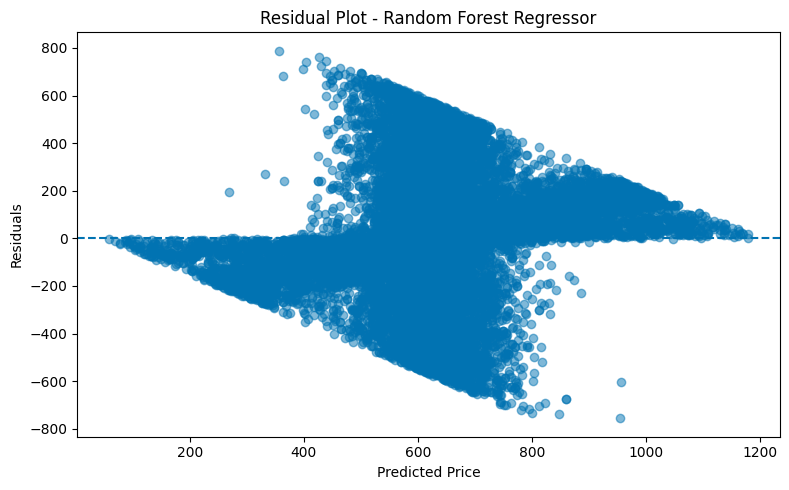

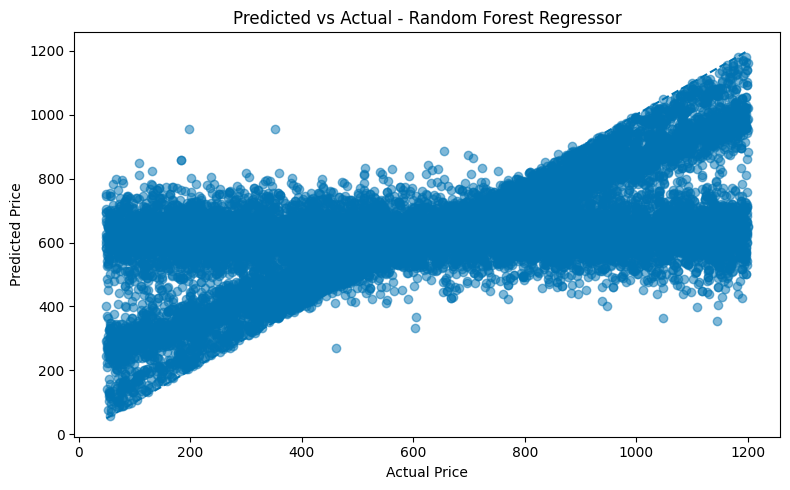

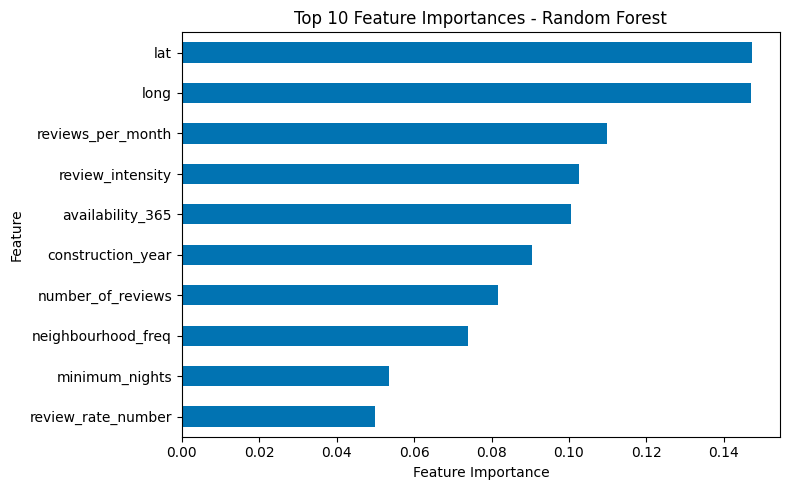

In [36]:
# Diagnostic plots for the best model: Random Forest Regressor

import matplotlib.pyplot as plt
import pandas as pd

# Predictions from the best Random Forest model
y_pred_best = rf.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred_best


# 1. Residual Plot
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regressor")

plt.tight_layout()
plt.show()


# 2. Predicted vs Actual Plot
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_best, alpha=0.5)

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual - Random Forest Regressor")

plt.tight_layout()
plt.show()


# 3. Random Forest Feature Importance
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))

top_features.sort_values().plot(kind='barh')

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()